In [18]:
# Import the libraries needed for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#display setting
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [19]:
# Load all the databasets into pandas DataFrames
products = pd.read_csv("C:\\Users\\HP\\Documents\\EMADE\\Python Training\\EmadeProducts.csv")
stores = pd.read_csv("C:\\Users\\HP\\Documents\\EMADE\\Python Training\\EmadeStores.csv")
customers = pd.read_csv("C:\\Users\HP\\Documents\\EMADE\\Python Training\\EmadeCustomers.csv")
orders = pd.read_csv("C:\\Users\\HP\\Documents\\EMADE\\Python Training\\EmadeOrders.csv")
stocks = pd.read_csv("C:\\Users\\HP\\Documents\\EMADE\\Python Training\\EmadeStocks.csv")
categories = pd.read_csv("C:\\Users\\HP\\Documents\\EMADE\\Python Training\\EmadeCategories.csv")
staffs = pd.read_csv("C:\\Users\\HP\\Documents\\EMADE\\Python Training\\EmadeStaffs.csv")
orderitems = pd.read_csv("C:\\Users\\HP\\Documents\\EMADE\\Python Training\\EmadeOrderItems.csv")
brands = pd.read_csv("C:\\Users\\HP\\Documents\\EMADE\\Python Training\\EmadeBrands.csv")

In [24]:
print("brands")
display(brands.head())

print("categories")
display(categories.head())

print("customers")
display(customers.head())

print("order Items")
display(orderitems.head())

print("orders")
display(orders.head())

print("products")
display(products.head())

print("stores")
display(stores.head())

brands


,brand_id,brand_name
0,1,Electra
1,2,Haro
2,3,Heller
3,4,Pure Cycles
4,5,Ritchey


categories


,category_id,category_name
0,1,Children Bicycles
1,2,Comfort Bicycles
2,3,Cruisers Bicycles
3,4,Cyclocross Bicycles
4,5,Electric Bikes


customers


...

,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id
0,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2
1,2,1212,4,2016-01-01,2016-01-04,2016-01-03,2,6
2,3,523,4,2016-01-02,2016-01-05,2016-01-03,2,7
3,4,175,4,2016-01-03,2016-01-04,2016-01-05,1,3
4,5,1324,4,2016-01-03,2016-01-06,2016-01-06,2,6


products


,product_id,product_name,brand_id,category_id,model_year,list_price
0,1,Trek 820 - 2016,9,6,2016,379.99
1,2,Ritchey Timberwolf Frameset - 2016,5,6,2016,749.99
2,3,Surly Wednesday Frameset - 2016,8,6,2016,999.99
3,4,Trek Fuel EX 8 29 - 2016,9,6,2016,2899.99
4,5,Heller Shagamaw Frame - 2016,3,6,2016,1320.99


stores


,store_id,store_name,phone,email,street,city,state,zip_code
0,1,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060
1,2,Baldwin Bikes,(516) 379-8888,baldwin@bikes.shop,4200 Chestnut Lane,Baldwin,NY,11432
2,3,Rowlett Bikes,(972) 530-5555,rowlett@bikes.shop,8000 Fairway Avenue,Rowlett,TX,75088


In [28]:
# Preview the datasets
def print_dataframe_columns(dataframes: dict) -> None:
    """
    Print the column names for each dataframe in a clean, aligned format.
    
    Args:
        dataframes (dict): Dictionary mapping dataframe names to pandas DataFrames.
    """
    # Find the longest dataframe name for alignment
    max_name_length = max(len(name) for name in dataframes.keys())
    
    # Print each dataframe's columns in alphabetical order
    for name in sorted(dataframes.keys()):
        formatted_name = f"{name.capitalize()} columns:"
        padding = " " * (max_name_length - len(name) + 2)
        
        # Format column list without brackets and quotes
        columns = dataframes[name].columns.tolist()
        clean_columns = ", ".join(str(col) for col in columns)
        
        print(f"{formatted_name}{padding}{clean_columns}")


# Dictionary of dataframes
dataframes = {
    "products":   products,
    "stores":     stores,
    "customers":  customers,
    "orders":     orders,
    "stocks":     stocks,
    "categories": categories,
    "staffs":     staffs,
    "orderitems": orderitems,
    "brands":     brands
}

# Print columns for all dataframes
print_dataframe_columns(dataframes)

Brands columns:      brand_id, brand_name
Categories columns:  category_id, category_name
Customers columns:   customer_id, first_name, last_name, phone, email, street, city, state, zip_code
Orderitems columns:  order_id, item_id, product_id, quantity, list_price, discount
Orders columns:      order_id, customer_id, order_status, order_date, required_date, shipped_date, store_id, staff_id
Products columns:    product_id, product_name, brand_id, category_id, model_year, list_price
Staffs columns:      staff_id, first_name, last_name, email, phone, active, store_id, manager_id
Stocks columns:      store_id, product_id, quantity
Stores columns:      store_id, store_name, phone, email, street, city, state, zip_code


In [32]:
# Check dataset shapes and columns
datasets = {
    "brands": brands,
    "categories": categories,
    "customers": customers,
    "orderitems": orderitems,
    "orders": orders,
    "products": products,
    "staffs": staffs,
    "stocks": stocks,
    "stores": stores
}

for name, data in datasets.items():
    print(f"\n{name.upper()} SHAPE: {data.shape}")
    print(data.columns.tolist())


BRANDS SHAPE: (9, 2)
['brand_id', 'brand_name']

CATEGORIES SHAPE: (7, 2)
['category_id', 'category_name']

CUSTOMERS SHAPE: (1445, 9)
['customer_id', 'first_name', 'last_name', 'phone', 'email', 'street', 'city', 'state', 'zip_code']

ORDERITEMS SHAPE: (4722, 6)
['order_id', 'item_id', 'product_id', 'quantity', 'list_price', 'discount']

ORDERS SHAPE: (1615, 8)
['order_id', 'customer_id', 'order_status', 'order_date', 'required_date', 'shipped_date', 'store_id', 'staff_id']

PRODUCTS SHAPE: (321, 6)
['product_id', 'product_name', 'brand_id', 'category_id', 'model_year', 'list_price']

STAFFS SHAPE: (10, 8)
['staff_id', 'first_name', 'last_name', 'email', 'phone', 'active', 'store_id', 'manager_id']

STOCKS SHAPE: (939, 3)
['store_id', 'product_id', 'quantity']

STORES SHAPE: (3, 8)
['store_id', 'store_name', 'phone', 'email', 'street', 'city', 'state', 'zip_code']


In [33]:
# Data cleaning
# Check missing values
for name, data in datasets.items():
    print(f"\nMissing values in {name.upper()}:")
    print(data.isnull().sum())


Missing values in BRANDS:
brand_id      0
brand_name    0
dtype: int64

Missing values in CATEGORIES:
category_id      0
category_name    0
dtype: int64

Missing values in CUSTOMERS:
customer_id       0
first_name        0
last_name         0
phone          1267
email             0
street            0
city              0
state             0
zip_code          0
dtype: int64

Missing values in ORDERITEMS:
order_id      0
item_id       0
product_id    0
quantity      0
list_price    0
discount      0
dtype: int64

Missing values in ORDERS:
order_id           0
customer_id        0
order_status       0
order_date         0
required_date      0
shipped_date     170
store_id           0
staff_id           0
dtype: int64

Missing values in PRODUCTS:
product_id      0
product_name    0
brand_id        0
category_id     0
model_year      0
list_price      0
dtype: int64

Missing values in STAFFS:
staff_id      0
first_name    0
last_name     0
email         0
phone         0
active        0
st

In [35]:
# Drop duplicates
for name, data in datasets.items():
    print(f"{name} duplicates before drop: {data.duplicated().sum()}")
    datasets[name] = data.drop_duplicates()
    print(f"{name} duplicates after drop: {datasets[name].duplicated().sum()}")

brands duplicates before drop: 0
brands duplicates after drop: 0
categories duplicates before drop: 0
categories duplicates after drop: 0
customers duplicates before drop: 0
customers duplicates after drop: 0
orderitems duplicates before drop: 0
orderitems duplicates after drop: 0
orders duplicates before drop: 0
orders duplicates after drop: 0
products duplicates before drop: 0
products duplicates after drop: 0
staffs duplicates before drop: 0
staffs duplicates after drop: 0
stocks duplicates before drop: 0
stocks duplicates after drop: 0
stores duplicates before drop: 0
stores duplicates after drop: 0


In [37]:
# Now assign them back:
brands = datasets["brands"]
categories = datasets["categories"]
customers = datasets["customers"]
order_items = datasets["orderitems"]
orders = datasets["orders"]
products = datasets["products"]
staffs = datasets["staffs"]
stocks = datasets["stocks"]
stores = datasets["stores"]

In [41]:
# Handle missing values
customers["phone"] = customers["phone"].fillna("Not Available")
orders["shipped_date"] = pd.to_datetime(orders["shipped_date"], errors="coerce")
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
orders["required_date"] = pd.to_datetime(orders["required_date"], errors="coerce")
staffs["manager_id"] = staffs["manager_id"].fillna(0)

In [42]:
# Merge datasets into one final dataframe called df
# This is the main analysis table.
df = order_items.merge(orders, on="order_id", how="left")
df = df.merge(products[["product_id", "product_name", "brand_id", "category_id", "model_year"]], 
              on="product_id", how="left")
df = df.merge(brands, on="brand_id", how="left")
df = df.merge(categories, on="category_id", how="left")
df = df.merge(customers[["customer_id", "city", "state"]], on="customer_id", how="left")
df = df.merge(stores[["store_id", "store_name", "city", "state"]], 
              on="store_id", how="left", suffixes=("_customer", "_store"))

display(df.head())
print(df.shape)

,order_id,item_id,product_id,quantity,list_price,discount,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id,product_name,brand_id,category_id,model_year,brand_name,category_name,city_customer,state_customer,store_name,city_store,state_store
0,1,1,20,1,599.99,0.20,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Electra Townie Original 7D EQ - Women's - 2016,1,3,2016,Electra,Cruisers Bicycles,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA
1,1,2,8,2,1799.99,0.07,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Trek Remedy 29 Carbon Frameset - 2016,9,6,2016,Trek,Mountain Bikes,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA
2,1,3,10,2,1549.00,0.05,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Surly Straggler - 2016,8,4,2016,Surly,Cyclocross Bicycles,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA
3,1,4,16,2,599.99,0.05,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Electra Townie Original 7D EQ - 2016,1,3,2016,Electra,Cruisers Bicycles,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA
4,1,5,4,1,2899.99,0.20,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Trek Fuel EX 8 29 - 2016,9,6,2016,Trek,Mountain Bikes,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA


(4722, 24)


In [43]:
# Create calculated columns
#These columns are important for revenue and discount analysis.
df["gross_sales"] = df["quantity"] * df["list_price"]
df["discount_amount"] = df["gross_sales"] * df["discount"]
df["revenue"] = df["gross_sales"] - df["discount_amount"]
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)

display(df.head())

,order_id,item_id,product_id,quantity,list_price,discount,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id,product_name,brand_id,category_id,model_year,brand_name,category_name,city_customer,state_customer,store_name,city_store,state_store,gross_sales,discount_amount,revenue,order_month
0,1,1,20,1,599.99,0.20,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Electra Townie Original 7D EQ - Women's - 2016,1,3,2016,Electra,Cruisers Bicycles,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA,599.99,119.9980,479.9920,2016-01
1,1,2,8,2,1799.99,0.07,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Trek Remedy 29 Carbon Frameset - 2016,9,6,2016,Trek,Mountain Bikes,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA,3599.98,251.9986,3347.9814,2016-01
2,1,3,10,2,1549.00,0.05,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Surly Straggler - 2016,8,4,2016,Surly,Cyclocross Bicycles,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA,3098.00,154.9000,2943.1000,2016-01
3,1,4,16,2,599.99,0.05,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Electra Townie Original 7D EQ - 2016,1,3,2016,Electra,Cruisers Bicycles,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA,1199.98,59.9990,1139.9810,2016-01
4,1,5,4,1,2899.99,0.20,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Trek Fuel EX 8 29 - 2016,9,6,2016,Trek,Mountain Bikes,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA,2899.99,579.9980,2319.9920,2016-01


In [44]:
# Descriptive statistics
# General descriptive statistics
display(df.describe(include="all"))

,order_id,item_id,product_id,quantity,list_price,discount,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id,product_name,brand_id,category_id,model_year,brand_name,category_name,city_customer,state_customer,store_name,city_store,state_store,gross_sales,discount_amount,revenue,order_month
count,4722.000000,4722.000000,4722.000000,4722.000000,4722.000000,4722.000000,4722.000000,4722.000000,4722,4722,4214,4722.000000,4722.000000,4722,4722.000000,4722.000000,4722.000000,4722,4722,4722,4722,4722,4722,4722,4722.000000,4722.000000,4722.000000,4722
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,278,NaN,NaN,NaN,9,7,195,3,3,3,3,NaN,NaN,NaN,35
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Electra Townie Original 21D - 2016,NaN,NaN,NaN,Electra,Cruisers Bicycles,Scarsdale,NY,Baldwin Bikes,Baldwin,NY,NaN,NaN,NaN,2018-04
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,193,NaN,NaN,NaN,1729,1378,61,3195,3195,3195,3195,NaN,NaN,NaN,385
mean,821.265354,2.262601,59.366158,1.498941,1212.707872,0.105373,659.057603,3.772342,2017-04-04 22:18:26.988564224,2017-04-06 16:56:25.006353152,2017-03-01 00:03:04.527764736,1.897289,5.871665,NaN,4.939221,3.767471,2016.630877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1816.812554,188.452419,1628.360135,NaN
min,1.000000,1.000000,2.000000,1.000000,89.990000,0.050000,1.000000,1.000000,2016-01-01 00:00:00,2016-01-03 00:00:00,2016-01-03 00:00:00,1.000000,2.000000,NaN,1.000000,1.000000,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.990000,5.499500,71.992000,NaN
25%,423.250000,1.000000,14.000000,1.000000,429.000000,0.050000,238.250000,4.000000,2016-09-06 12:00:00,2016-09-09 06:00:00,2016-08-23 00:00:00,2.000000,6.000000,NaN,1.000000,2.000000,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,539.980000,43.996000,474.981000,NaN
50%,828.500000,2.000000,28.000000,1.000000,599.990000,0.085000,646.500000,4.000000,2017-04-09 00:00:00,2017-04-10 00:00:00,2017-03-10 00:00:00,2.000000,6.000000,NaN,5.000000,3.000000,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,939.980000,89.800000,845.982000,NaN
75%,1226.000000,3.000000,84.000000,2.000000,1549.000000,0.200000,1052.000000,4.000000,2017-11-04 00:00:00,2017-11-06 00:00:00,2017-09-14 18:00:00,2.000000,7.000000,NaN,9.000000,6.000000,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999.980000,209.999300,1799.988750,NaN
max,1615.000000,5.000000,315.000000,2.000000,11999.990000,0.200000,1445.000000,4.000000,2018-12-28 00:00:00,2018-12-28 00:00:00,2018-04-02 00:00:00,3.000000,9.000000,NaN,9.000000,7.000000,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23999.980000,2399.998000,21599.982000,NaN


In [45]:
# Numerical descriptive statistics
display(df[["quantity", "list_price", "discount", "gross_sales", "discount_amount", "revenue"]].describe().round(2))

,quantity,list_price,discount,gross_sales,discount_amount,revenue
count,4722.0,4722.00,4722.00,4722.00,4722.00,4722.00
mean,1.5,1212.71,0.11,1816.81,188.45,1628.36
std,0.5,1352.80,0.06,2228.16,268.36,2017.92
min,1.0,89.99,0.05,89.99,5.50,71.99
25%,1.0,429.00,0.05,539.98,44.00,474.98
50%,1.0,599.99,0.08,939.98,89.80,845.98
75%,2.0,1549.00,0.20,1999.98,210.00,1799.99
max,2.0,11999.99,0.20,23999.98,2400.00,21599.98


In [46]:
# Brand-level analysis
#This helps you analyze each brand.
brand_summary = df.groupby("brand_name").agg(
    total_orders=("order_id", "nunique"),
    total_quantity=("quantity", "sum"),
    average_price=("list_price", "mean"),
    total_discount=("discount_amount", "sum"),
    total_revenue=("revenue", "sum")
).sort_values("total_revenue", ascending=False).round(2)

display(brand_summary)

,total_orders,total_quantity,average_price,total_discount,total_revenue
brand_name,,,,,
Trek,883,1839,2766.87,526627.26,4602754.35
Electra,1096,2612,519.39,138822.97,1205320.82
Surly,531,908,1165.93,113628.76,949507.06
Sun Bicycles,393,731,529.41,39924.76,341994.93
Haro,196,331,629.26,21712.14,185384.55
Heller,97,138,1400.04,22339.63,171459.08
Pure Cycles,232,376,441.95,16687.66,149476.34
Ritchey,77,118,749.99,9599.87,78898.95
Strider,16,25,194.99,529.27,4320.48


In [47]:
# Create helper functions for chart labels
def add_bar_labels(ax, fmt="{:,.0f}"):
    for p in ax.patches:
        height = p.get_height()
        if pd.notna(height):
            ax.annotate(
                fmt.format(height),
                (p.get_x() + p.get_width() / 2, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 5),
                textcoords="offset points"
            )

In [48]:
#Create brand colors
brand_names = sorted(df["brand_name"].dropna().unique())
brand_colors = plt.cm.tab10(np.linspace(0, 1, len(brand_names)))
brand_color_map = dict(zip(brand_names, brand_colors))

brand_color_map

{'Electra': array([0.12156863, 0.46666667, 0.70588235, 1.        ]),
 'Haro': array([1.        , 0.49803922, 0.05490196, 1.        ]),
 'Heller': array([0.17254902, 0.62745098, 0.17254902, 1.        ]),
 'Pure Cycles': array([0.83921569, 0.15294118, 0.15686275, 1.        ]),
 'Ritchey': array([0.54901961, 0.3372549 , 0.29411765, 1.        ]),
 'Strider': array([0.89019608, 0.46666667, 0.76078431, 1.        ]),
 'Sun Bicycles': array([0.49803922, 0.49803922, 0.49803922, 1.        ]),
 'Surly': array([0.7372549 , 0.74117647, 0.13333333, 1.        ]),
 'Trek': array([0.09019608, 0.74509804, 0.81176471, 1.        ])}

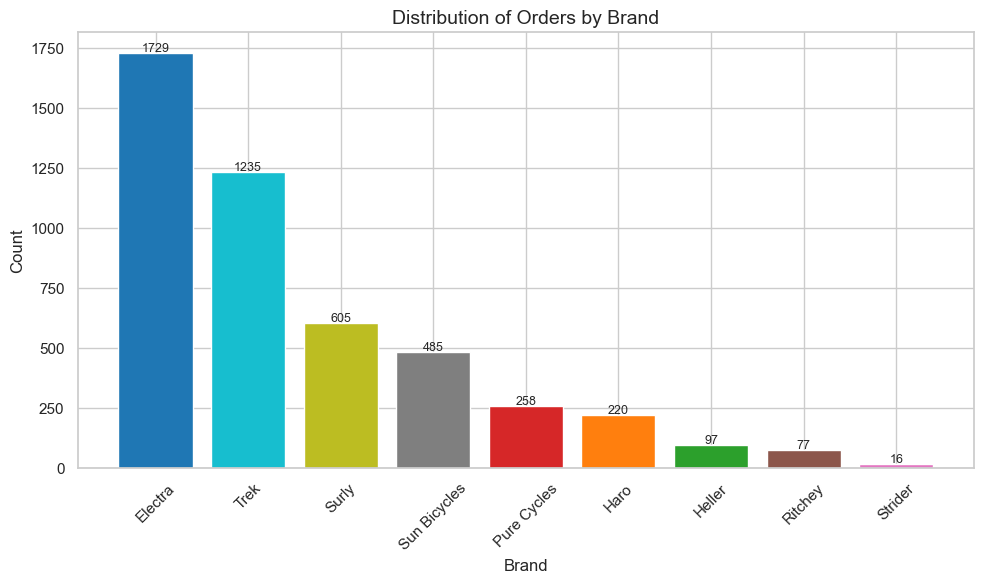

In [49]:
# Applicable visualizations
#Distribution of memberships with plans
#using brand distribution 
brand_dist = df["brand_name"].value_counts().reset_index()
brand_dist.columns = ["brand_name", "count"]

plt.figure(figsize=(10, 6))
ax = plt.bar(
    brand_dist["brand_name"],
    brand_dist["count"],
    color=[brand_color_map[b] for b in brand_dist["brand_name"]]
)

plt.title("Distribution of Orders by Brand", fontsize=14)
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)

for bar in ax:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 5, f"{int(y)}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

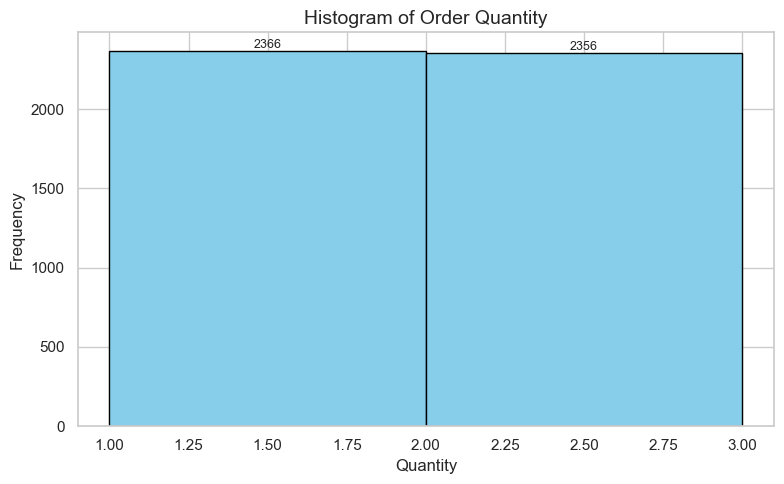

In [50]:
# Histogram replacement
#A histogram numeric variable, using order quantity distribution.
plt.figure(figsize=(8, 5))
counts, bins, patches = plt.hist(df["quantity"], bins=range(1, df["quantity"].max() + 2), edgecolor="black", color="skyblue")

plt.title("Histogram of Order Quantity", fontsize=14)
plt.xlabel("Quantity")
plt.ylabel("Frequency")

for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

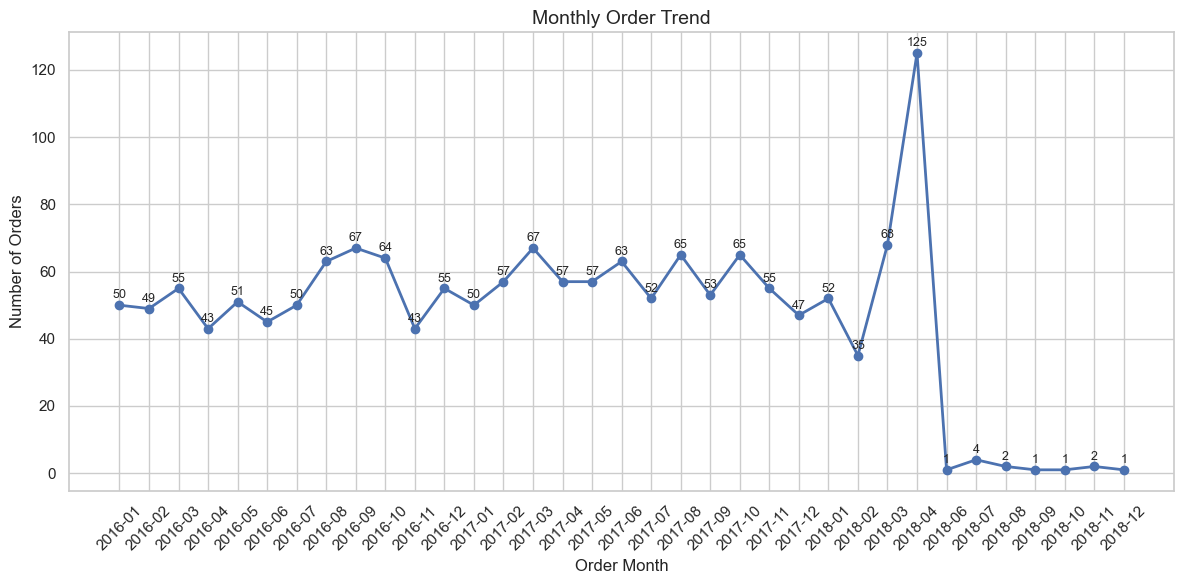

In [51]:
# Monthly order trend
monthly_orders = df.groupby("order_month").agg(
    total_orders=("order_id", "nunique")
).reset_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_orders["order_month"], monthly_orders["total_orders"], marker="o", linewidth=2)

plt.title("Monthly Order Trend", fontsize=14)
plt.xlabel("Order Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

for x, y in zip(monthly_orders["order_month"], monthly_orders["total_orders"]):
    plt.text(x, y + 2, f"{y}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

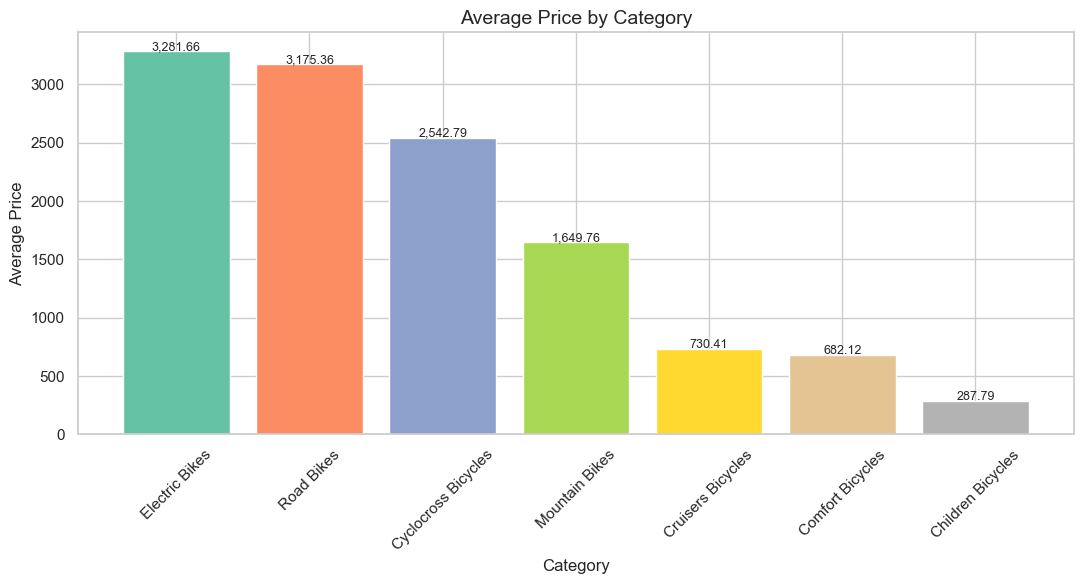

In [52]:
# Price distribution by category
#Using average price by category.
category_price = products.merge(categories, on="category_id", how="left")
category_price_summary = category_price.groupby("category_name", as_index=False)["list_price"].mean()
category_price_summary = category_price_summary.sort_values("list_price", ascending=False)

category_colors = plt.cm.Set2(np.linspace(0, 1, len(category_price_summary)))

plt.figure(figsize=(11, 6))
bars = plt.bar(category_price_summary["category_name"], category_price_summary["list_price"], color=category_colors)

plt.title("Average Price by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 10, f"{y:,.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

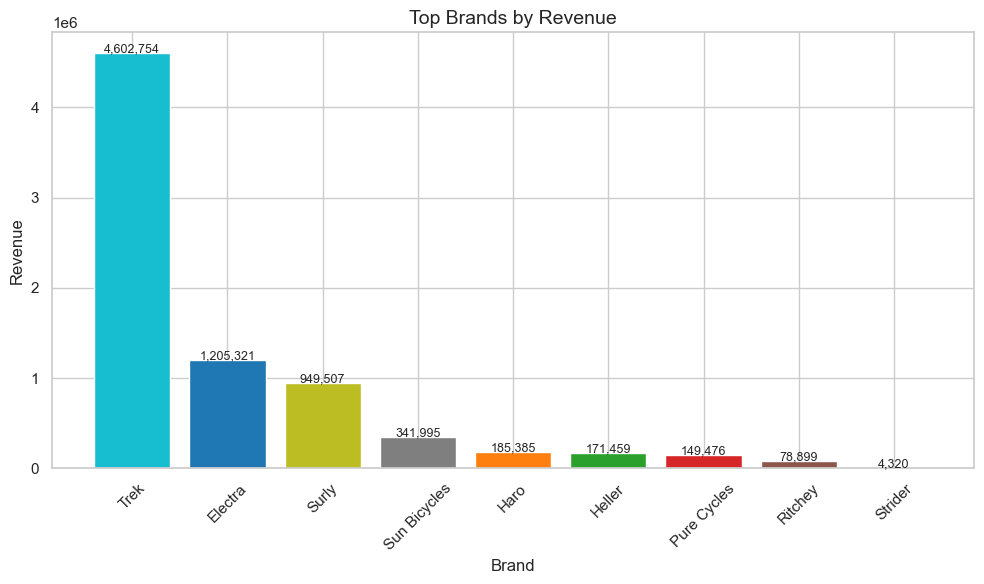

In [53]:
# Top brands by revenue
# This is one of the most important charts in my project.
top_brands = df.groupby("brand_name", as_index=False)["revenue"].sum()
top_brands = top_brands.sort_values("revenue", ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(
    top_brands["brand_name"],
    top_brands["revenue"],
    color=[brand_color_map[b] for b in top_brands["brand_name"]]
)

plt.title("Top Brands by Revenue", fontsize=14)
plt.xlabel("Brand")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 10000, f"{y:,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

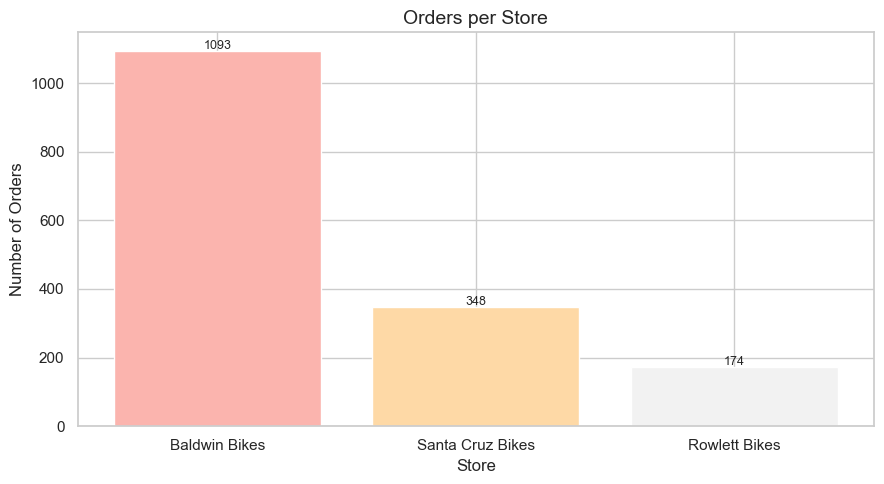

In [54]:
# Orders per store
orders_per_store = df.groupby("store_name", as_index=False)["order_id"].nunique()
orders_per_store = orders_per_store.sort_values("order_id", ascending=False)

store_colors = plt.cm.Pastel1(np.linspace(0, 1, len(orders_per_store)))

plt.figure(figsize=(9, 5))
bars = plt.bar(orders_per_store["store_name"], orders_per_store["order_id"], color=store_colors)

plt.title("Orders per Store", fontsize=14)
plt.xlabel("Store")
plt.ylabel("Number of Orders")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 5, f"{int(y)}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

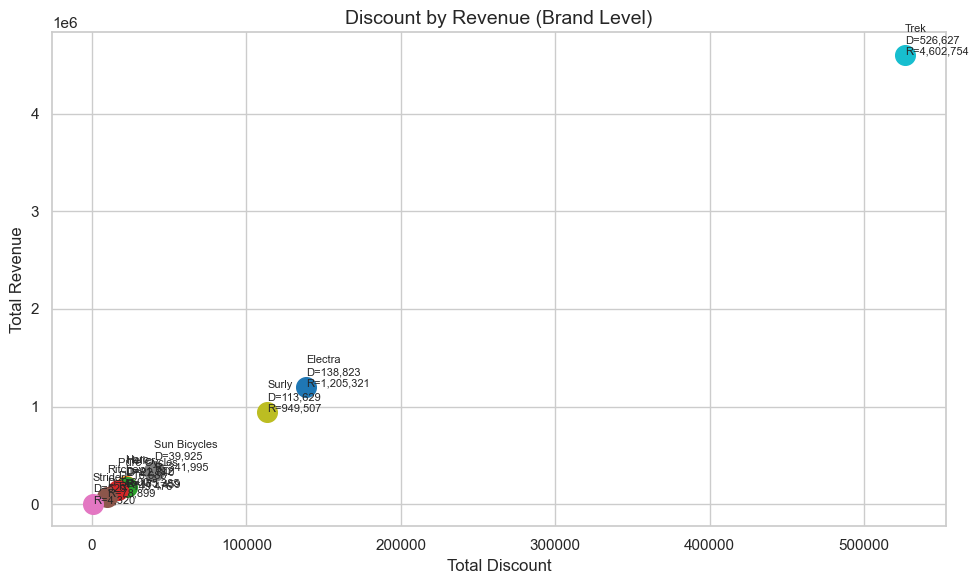

In [55]:
# Discount by revenue
#Using scatter plot by brand.
brand_discount_revenue = df.groupby("brand_name", as_index=False).agg(
    total_discount=("discount_amount", "sum"),
    total_revenue=("revenue", "sum")
)

plt.figure(figsize=(10, 6))

for _, row in brand_discount_revenue.iterrows():
    plt.scatter(
        row["total_discount"],
        row["total_revenue"],
        s=200,
        color=brand_color_map[row["brand_name"]],
        label=row["brand_name"]
    )
    plt.text(
        row["total_discount"],
        row["total_revenue"],
        f"{row['brand_name']}\nD={row['total_discount']:,.0f}\nR={row['total_revenue']:,.0f}",
        fontsize=8,
        ha="left"
    )

plt.title("Discount by Revenue (Brand Level)", fontsize=14)
plt.xlabel("Total Discount")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

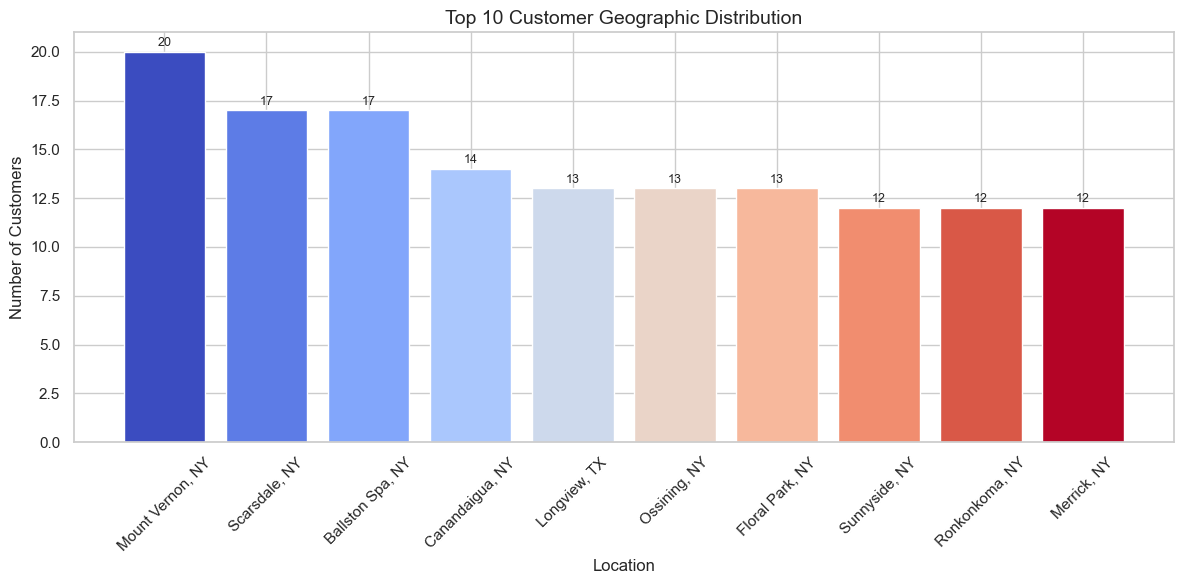

In [56]:
#Customer geographic distribution
#Using top customer cities.
geo_dist = df.groupby(["state_customer", "city_customer"], as_index=False)["customer_id"].nunique()
geo_dist.columns = ["state", "city", "customer_count"]
geo_dist["location"] = geo_dist["city"] + ", " + geo_dist["state"]
geo_dist = geo_dist.sort_values("customer_count", ascending=False).head(10)

geo_colors = plt.cm.coolwarm(np.linspace(0, 1, len(geo_dist)))

plt.figure(figsize=(12, 6))
bars = plt.bar(geo_dist["location"], geo_dist["customer_count"], color=geo_colors)

plt.title("Top 10 Customer Geographic Distribution", fontsize=14)
plt.xlabel("Location")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.3, f"{int(y)}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [57]:
#Final brand conclusion
#final ranking 
final_brand_report = df.groupby("brand_name").agg(
    total_orders=("order_id", "nunique"),
    total_quantity=("quantity", "sum"),
    average_discount=("discount", "mean"),
    total_discount=("discount_amount", "sum"),
    total_revenue=("revenue", "sum")
).sort_values("total_revenue", ascending=False).round(2)

display(final_brand_report)

,total_orders,total_quantity,average_discount,total_discount,total_revenue
brand_name,,,,,
Trek,883,1839,0.11,526627.26,4602754.35
Electra,1096,2612,0.10,138822.97,1205320.82
Surly,531,908,0.11,113628.76,949507.06
Sun Bicycles,393,731,0.11,39924.76,341994.93
Haro,196,331,0.11,21712.14,185384.55
Heller,97,138,0.11,22339.63,171459.08
Pure Cycles,232,376,0.10,16687.66,149476.34
Ritchey,77,118,0.11,9599.87,78898.95
Strider,16,25,0.12,529.27,4320.48


Project Summary
This project analyzes bike sales data using Python in Jupyter Notebook. The datasets were loaded, cleaned, checked for missing values, and duplicates were removed. A final merged dataframe df was created using orders, order items, products, brands, categories, customers, and stores. Descriptive statistics were generated, and visualizations were used to analyze monthly order trends, category pricing, top brands by revenue, store performance, discount versus revenue, and customer geographic distribution. Since the dataset does not contain membership or plan columns, brand distribution analysis was used as the closest standard business substitute.